# Patryk Kożuch

## Downloading data

In [1]:
BASE_URL = "https://opendata.rijdendetreinen.nl/public"

In [2]:
# Distances
# ! wget --quiet {BASE_URL}/tariff-distances/tariff-distances-2022-01.csv -O data/distances-2022.csv

In [3]:
# Stations
# ! wget --quiet {BASE_URL}/stations/stations-2023-09.csv -O data/stations-2023.csv

In [4]:
# Disruptions
# for i in range(2011, 2024):
#     ! wget --quiet {BASE_URL}/disruptions/disruptions-{i}.csv -O data/disruptions-{i}.csv

In [5]:
# Services
# for i in range(2019, 2025):
#     ! wget --quiet {BASE_URL}/services/services-{i}.csv.gz -O data/services-{i}.csv.gz && gzip -f -d data/services-{i}.csv.gz

In [6]:
# Services in 2025
# for i in range(1, 10):
#     ! wget --quiet {BASE_URL}/services/services-2025-0{i}.csv.gz -O data/services-2025-0{i}.csv.gz && gzip -f -d data/services-2025-0{i}.csv.gz

# DuckDB

In [7]:
import duckdb

## 2. Stations table

In [8]:
db = duckdb.connect('data/duckdb_homework.db')

In [9]:
db.sql("""
CREATE TABLE IF NOT EXISTS stations AS
FROM "data/stations-2023.csv"
""")

## 3. Distances tables

In [10]:
db.sql("""
DROP TABLE IF EXISTS distances;
CREATE TABLE distances AS
    FROM read_csv(
        "data/distances-2022.csv",
        nullstr = 'XXX'
    );
""")

In [11]:
db.sql("""
SELECT #1, #2, #3, #4, #5, #6, #7, #8, #9
FROM distances
LIMIT 8;
""")

┌─────────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┬───────┐
│ Station │  AC   │  AH   │  AHP  │ AHPR  │  AHZ  │  AKL  │  AKM  │  ALM  │
│ varchar │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │ int64 │
├─────────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┼───────┤
│ AC      │  NULL │    82 │    83 │    85 │    90 │    71 │   188 │    32 │
│ AH      │    82 │  NULL │     1 │     3 │     8 │    77 │   153 │    98 │
│ AHP     │    83 │     1 │  NULL │     2 │     9 │    78 │   152 │    99 │
│ AHPR    │    85 │     3 │     2 │  NULL │    11 │    80 │   150 │   101 │
│ AHZ     │    90 │     8 │     9 │    11 │  NULL │    69 │   161 │   106 │
│ AKL     │    71 │    77 │    78 │    80 │    69 │  NULL │   211 │    96 │
│ AKM     │   188 │   153 │   152 │   150 │   161 │   211 │  NULL │   158 │
│ ALM     │    32 │    98 │    99 │   101 │   106 │    96 │   158 │  NULL │
└─────────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┴───────┘

In [12]:
db.sql("""
DROP TABLE IF EXISTS distances_long;
CREATE TABLE distances_long AS
    UNPIVOT distances
    ON COLUMNS (* EXCLUDE station)
    INTO NAME other_station VALUE distance;
""")

## 4. Disruptions in postgres

In [13]:
db.sql("INSTALL postgres; LOAD postgres")

In [14]:
conn_string = "host=localhost user=postgres password=postgres dbname=postgres"
db.sql(f"""
ATTACH IF NOT EXISTS '{conn_string}' AS postgres_db (TYPE postgres);
""")

In [15]:
db.sql("""
DROP TABLE IF EXISTS postgres_db.disruptions;
CREATE TABLE postgres_db.disruptions AS
FROM "data/disruptions-*.csv"
""")

## 5. Services to parquet

In [16]:
db.sql("""
COPY (SELECT * FROM "data/services-*.csv") TO "data/services_all.parquet" (FORMAT parquet, COMPRESSION zstd);
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [17]:
db.sql("""
CREATE TABLE services AS
FROM "data/services_all.parquet"
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## 7. Queries

In [18]:
db.sql("""SELECT code FROM stations WHERE name_medium='Amsterdam C.'""")

┌─────────┐
│  code   │
│ varchar │
├─────────┤
│ ASD     │
└─────────┘

In [19]:
db.sql("""
SELECT COUNT(*)
    FROM services
    WHERE "Stop:Departure time" IS NOT NULL
        AND "Stop:Station code" = 'ASD'
""")

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      1871852 │
└──────────────┘

In [20]:
db.sql("""
SELECT "Service:Type", AVG("Stop:Arrival delay") as "Average delay"
    FROM services
    GROUP BY "Service:Type"
    ORDER BY "Average delay" DESC
""")

┌──────────────────────┬────────────────────┐
│     Service:Type     │   Average delay    │
│       varchar        │       double       │
├──────────────────────┼────────────────────┤
│ Alpen Express        │  31.84254143646409 │
│ Krokus Express       │ 18.304347826086957 │
│ European Sleeper     │ 14.730917608156517 │
│ Nightjet             │  9.256974238121135 │
│ Eurostar             │  7.221416941972401 │
│ ICE International    │  5.482790573052148 │
│ Thalys               │ 5.3961896909446025 │
│ Int. Trein           │ 4.9727022780832675 │
│ Nachttrein           │ 3.7960975609756096 │
│ Stoomtrein           │  3.366863905325444 │
│     ·                │                 ·  │
│     ·                │                 ·  │
│     ·                │                 ·  │
│ Snelbus i.p.v. trein │                0.0 │
│ Belbus ipv trein     │                0.0 │
│ Metro i.p.v. trein   │                0.0 │
│ stoptrein            │                0.0 │
│ Belbus               │          

In [21]:
db.sql("""
SELECT YEAR("start_time") AS "Year", MODE("cause_en" ORDER BY "cause_en" ASC) as "Most frequent"
    FROM postgres_db.disruptions
    GROUP BY "Year"
""")

┌───────┬───────────────────┐
│ Year  │   Most frequent   │
│ int64 │      varchar      │
├───────┼───────────────────┤
│  2011 │ broken down train │
│  2012 │ points failure    │
│  2020 │ broken down train │
│  2015 │ broken down train │
│  2023 │ broken down train │
│  2014 │ broken down train │
│  2018 │ broken down train │
│  2021 │ broken down train │
│  2013 │ points failure    │
│  2019 │ broken down train │
│  2016 │ broken down train │
│  2017 │ broken down train │
│  2022 │ broken down train │
├───────┴───────────────────┤
│ 13 rows         2 columns │
└───────────────────────────┘

In [22]:
db.sql("""
SELECT COUNT(*) AS "Trains count"
    FROM services
    WHERE "Stop:Station name" LIKE '%Amsterdam%'
        AND "Stop:Arrival time" IS NULL
""")

┌──────────────┐
│ Trains count │
│    int64     │
├──────────────┤
│      1243175 │
└──────────────┘

In [23]:
db.sql("""
SELECT COUNT(DISTINCT "Service:RDT-ID") / (SELECT COUNT(DISTINCT "Service:RDT-ID") FROM services) AS "Abroad services fraction"
    FROM services
    JOIN stations ON "Stop:Station code" = "code"
    WHERE country != 'NL'
        AND "Stop:Departure time" IS NULL
""")

┌──────────────────────────┐
│ Abroad services fraction │
│          double          │
├──────────────────────────┤
│     0.037142935338268394 │
└──────────────────────────┘

In [24]:
db.sql("""
SELECT station, other_station, distance FROM distances_long
    JOIN stations AS a ON distances_long.station = a.code
    JOIN stations AS b ON distances_long.other_station = b.code
    WHERE a.country = 'NL' AND b.country = 'NL'
    ORDER BY distance DESC
    LIMIT 1
""")

┌─────────┬───────────────┬──────────┐
│ Station │ other_station │ distance │
│ varchar │    varchar    │  int64   │
├─────────┼───────────────┼──────────┤
│ VS      │ EEM           │      426 │
└─────────┴───────────────┴──────────┘

<Axes: xlabel='Service:Company'>

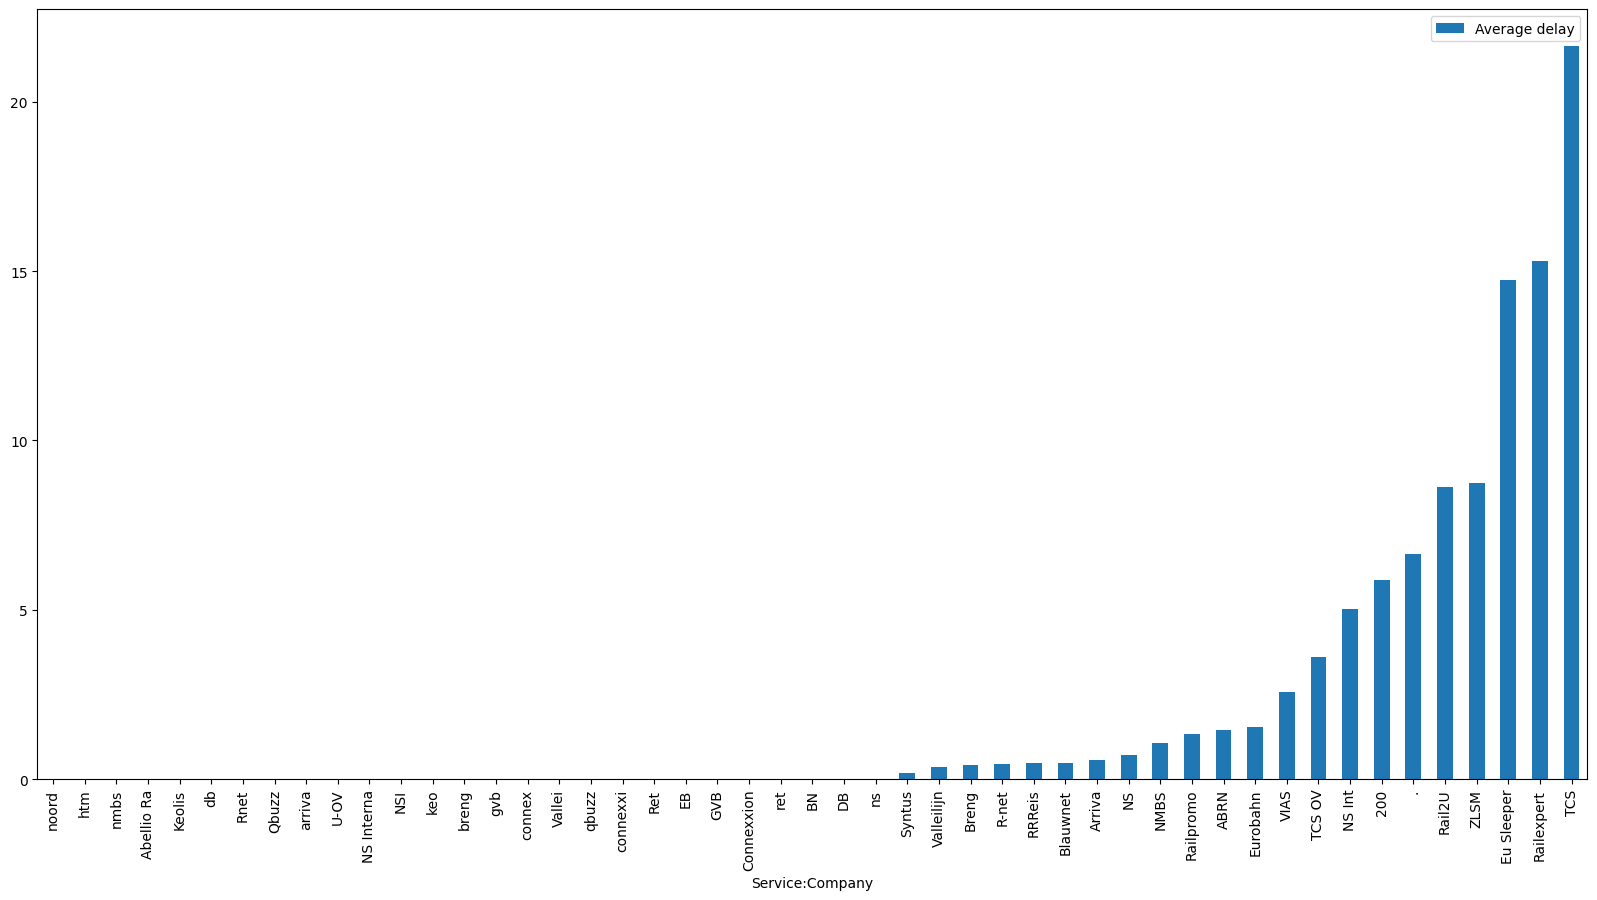

In [25]:
average_delay_per_company_df = db.sql("""
SELECT "Service:Company", AVG("Stop:Arrival delay") AS "Average delay"
    FROM services
    GROUP BY "Service:Company"
    ORDER BY "Average delay"
""").df()

average_delay_per_company_df.plot.bar(x="Service:Company", y="Average delay", figsize=(20, 10))

<Axes: xlabel='Year'>

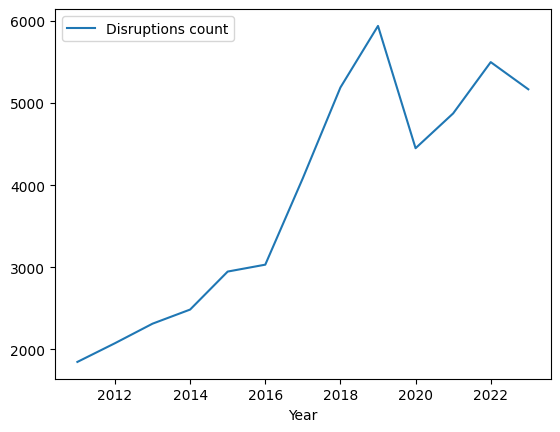

In [26]:
disruptions_per_year_df = db.sql("""
SELECT YEAR(start_time) AS "Year", COUNT(DISTINCT rdt_id) as "Disruptions count"
    FROM postgres_db.disruptions
    GROUP BY "Year"
    ORDER BY "Year"
""").df()

disruptions_per_year_df.plot(x="Year", y="Disruptions count")

<Axes: xlabel='Year'>

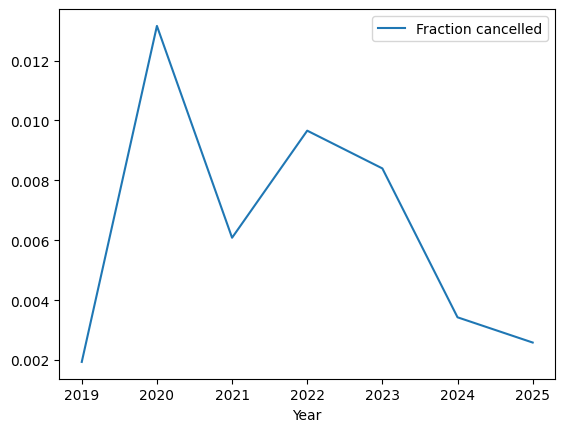

In [27]:
cancelled_per_year_df = db.sql("""
SELECT
    YEAR("Service:Date") as "Year",
    COUNT(DISTINCT "Service:RDT-ID") / (SELECT COUNT(DISTINCT "Service:RDT-ID") FROM services) AS "Fraction cancelled"
    FROM services
    WHERE "Service:Completely cancelled"
    GROUP BY "Year"
    ORDER BY "Year"
""").df()

cancelled_per_year_df.plot(x="Year", y="Fraction cancelled")

## 8. Service lengths

In [28]:
db.sql("""
SELECT row_number() OVER (PARTITION BY "Service:RDT-ID" ORDER BY "Stop:Arrival time" ASC) FROM services
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────────────────────────────────────────────────────────────────────────────┐
│ row_number() OVER (PARTITION BY "Service:RDT-ID" ORDER BY "Stop:Arrival time" ASC) │
│                                       int64                                        │
├────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                  8 │
│                                                                                  9 │
│                                                                                 10 │
│                                                                                 11 │
│                                                                                  1 │
│                                                                                  2 │
│                                                                                  3 │
│                                          

In [112]:
db.sql("""
    DROP TABLE IF EXISTS connection_pairs;
    CREATE TEMP TABLE connection_pairs
    AS SELECT
        "Service:RDT-ID",
        row_number() OVER (PARTITION BY "Service:RDT-ID" ORDER BY "Stop:Departure time" ASC NULLS LAST) AS "Station order",
        LAG("Stop:Station code") OVER (PARTITION BY "Service:RDT-ID" ORDER BY "Stop:Departure time" ASC NULLS LAST) AS "Previous station",
        "Stop:Station code" AS "Current station",
        FROM services
        ORDER BY "Service:RDT-ID", "Stop:Departure time"
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [117]:
db.sql("""
    DROP TABLE IF EXISTS connection_pairs_distances;
    CREATE TEMP TABLE connection_pairs_distances
    AS SELECT
        "Service:RDT-ID",
        "Station order",
        "Previous station",
        "Current station",
        COALESCE(dl.distance, 0) AS "Distance"
    FROM connection_pairs AS cp
        LEFT JOIN distances_long AS dl
        ON (cp."Current station" = dl.station AND cp."Previous station" = dl.other_station);
""")

In [119]:
db.sql("""
    DROP TABLE IF EXISTS cumulative_distances;
    CREATE TEMP TABLE cumulative_distances AS
    SELECT
        "Service:RDT-ID",
        "Previous station" AS start_station_code,
        "Current station" AS end_station_code,
        "Station order",
        "Distance",
        COALESCE(SUM("Distance") OVER (PARTITION BY "Service:RDT-ID" ORDER BY "Station order" ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW), 0) AS cumulative_distance
    FROM connection_pairs_distances;
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [131]:
db.sql("""
    DROP TABLE IF EXISTS station_connections;
    CREATE TABLE station_connections AS
    SELECT
        a."Service:RDT-ID",
        a.start_station_code,
        b.end_station_code,
        b.cumulative_distance - a.cumulative_distance + a.distance AS distance
    FROM cumulative_distances a
    JOIN cumulative_distances b
      ON a."Service:RDT-ID" = b."Service:RDT-ID"
     AND a."Station order" <= b."Station order"
     AND a.start_station_code IS NOT NULL
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [120]:
db.sql("""
    SELECT "Stop:Station name", "Stop:Station code", "Stop:Arrival time", "Stop:Departure time"
    FROM services
        WHERE "Service:RDT-ID" = 738805
        ORDER BY "Stop:Departure time"
""")

┌─────────────────────────┬───────────────────┬─────────────────────┬─────────────────────┐
│    Stop:Station name    │ Stop:Station code │  Stop:Arrival time  │ Stop:Departure time │
│         varchar         │      varchar      │      timestamp      │      timestamp      │
├─────────────────────────┼───────────────────┼─────────────────────┼─────────────────────┤
│ Utrecht Centraal        │ UT                │ NULL                │ 2019-01-01 01:17:00 │
│ Amsterdam Bijlmer ArenA │ ASB               │ 2019-01-01 01:34:00 │ 2019-01-01 01:34:00 │
│ Amsterdam Centraal      │ ASD               │ 2019-01-01 01:44:00 │ 2019-01-01 01:46:00 │
│ Schiphol Airport        │ SHL               │ 2019-01-01 02:01:00 │ 2019-01-01 02:05:00 │
│ Leiden Centraal         │ LEDN              │ 2019-01-01 02:21:00 │ 2019-01-01 02:23:00 │
│ Den Haag HS             │ GV                │ 2019-01-01 02:37:00 │ 2019-01-01 02:38:00 │
│ Delft                   │ DT                │ 2019-01-01 02:45:00 │ 2019-01-01

In [121]:
db.sql("""
    SELECT * FROM connection_pairs_distances WHERE "Service:RDT-ID" = 738805
""")

┌────────────────┬───────────────┬──────────────────┬─────────────────┬──────────┐
│ Service:RDT-ID │ Station order │ Previous station │ Current station │ Distance │
│     int64      │     int64     │     varchar      │     varchar     │  int64   │
├────────────────┼───────────────┼──────────────────┼─────────────────┼──────────┤
│         738805 │             2 │ UT               │ ASB             │       29 │
│         738805 │             3 │ ASB              │ ASD             │       10 │
│         738805 │             4 │ ASD              │ SHL             │       19 │
│         738805 │             5 │ SHL              │ LEDN            │       29 │
│         738805 │             6 │ LEDN             │ GV              │       16 │
│         738805 │             7 │ GV               │ DT              │        8 │
│         738805 │             8 │ DT               │ RTD             │       14 │
│         738805 │             1 │ NULL             │ UT              │        0 │
└───

In [122]:
db.sql("""
    SELECT * FROM cumulative_distances WHERE "Service:RDT-ID" = 738805 ORDER BY cumulative_distance
""")

┌────────────────┬────────────────────┬──────────────────┬───────────────┬──────────┬─────────────────────┐
│ Service:RDT-ID │ start_station_code │ end_station_code │ Station order │ Distance │ cumulative_distance │
│     int64      │      varchar       │     varchar      │     int64     │  int64   │       int128        │
├────────────────┼────────────────────┼──────────────────┼───────────────┼──────────┼─────────────────────┤
│         738805 │ NULL               │ UT               │             1 │        0 │                   0 │
│         738805 │ UT                 │ ASB              │             2 │       29 │                  29 │
│         738805 │ ASB                │ ASD              │             3 │       10 │                  39 │
│         738805 │ ASD                │ SHL              │             4 │       19 │                  58 │
│         738805 │ SHL                │ LEDN             │             5 │       29 │                  87 │
│         738805 │ LEDN     

In [132]:
db.sql("""
    SELECT * FROM station_connections WHERE "Service:RDT-ID" = 738805 ORDER BY start_station_code
""").show(max_rows=50)

┌────────────────┬────────────────────┬──────────────────┬──────────┐
│ Service:RDT-ID │ start_station_code │ end_station_code │ distance │
│     int64      │      varchar       │     varchar      │  int128  │
├────────────────┼────────────────────┼──────────────────┼──────────┤
│         738805 │ ASB                │ SHL              │       29 │
│         738805 │ ASB                │ ASD              │       10 │
│         738805 │ ASB                │ GV               │       74 │
│         738805 │ ASB                │ DT               │       82 │
│         738805 │ ASB                │ RTD              │       96 │
│         738805 │ ASB                │ LEDN             │       58 │
│         738805 │ ASD                │ LEDN             │       48 │
│         738805 │ ASD                │ SHL              │       19 │
│         738805 │ ASD                │ GV               │       64 │
│         738805 │ ASD                │ DT               │       72 │
│         738805 │ A

In [133]:
db.sql("""
    SELECT * FROM station_connections ORDER BY distance DESC LIMIT 1
""")

┌────────────────┬────────────────────┬──────────────────┬──────────┐
│ Service:RDT-ID │ start_station_code │ end_station_code │ distance │
│     int64      │      varchar       │     varchar      │  int128  │
├────────────────┼────────────────────┼──────────────────┼──────────┤
│        7122512 │ GS                 │ STV              │     2816 │
└────────────────┴────────────────────┴──────────────────┴──────────┘

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

<Axes: ylabel='Frequency'>

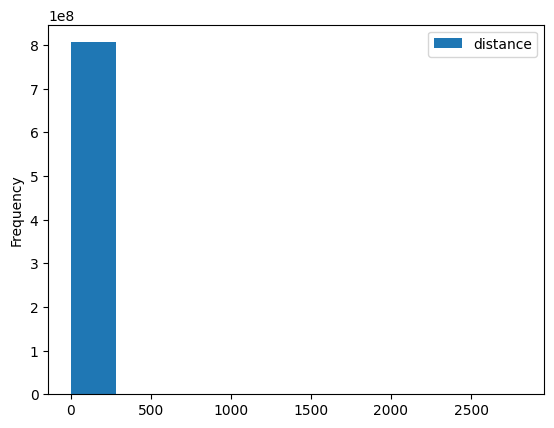

In [134]:
stations_connections_df = db.sql("SELECT distance FROM station_connections").df()

<Axes: ylabel='Frequency'>

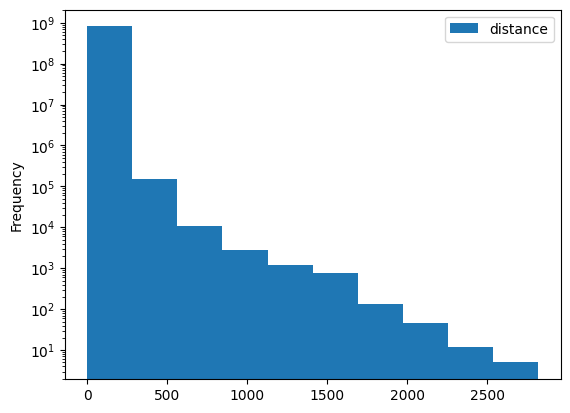

In [135]:
stations_connections_df.plot.hist(log=True)